# Problem Statement

Predict whether a patient has diabetes based on diagnostic measurements.

Target:
Outcome

Type:
Binary Classification

In [249]:
import joblib 
import dagshub 
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [250]:
# Data Ingestion
df = pd.read_csv('diabetes.csv')
df = df.copy()

In [251]:
# Understanding the DataSet (EDA)
df.shape

(768, 9)

In [252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [253]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [254]:
df.duplicated().sum()

np.int64(0)

In [255]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [256]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [257]:
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

(df[cols] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [258]:
(df[cols] == 0).sum().sort_values(ascending=False)

Insulin          374
SkinThickness    227
BloodPressure     35
BMI               11
Glucose            5
dtype: int64

In [259]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [260]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [261]:
# Analyzing the distribution of your target variable.
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [262]:
df["Outcome"].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [263]:
# data cleaning
# Replace invalid values
df[cols] = df[cols].replace(0, np.nan)
(df[cols] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [264]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [265]:
# Separate features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [266]:
# Split Dataset
# Used stratify to keeps class distribution balanced.
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# validation split for threshold optimization is implemented to avoids data leakage
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Split training portion again
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,   # 0.25 × 0.80 = 0.20
    stratify=y_train_full,
    random_state=42
)

In [267]:
# Data preprocessing & Training pipeline
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

fitted_models = {}

for name, model in models.items():

    if name == 'Logistic Regression':
        # Pre-Processing
        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])

    # Training
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

lr = fitted_models["Logistic Regression"]
rf = fitted_models["Random Forest"]
xgb = fitted_models["XGBoost"]
cb = fitted_models["CatBoost"]


In [268]:
# Evaluate Models
results = []

for model in [lr, rf, xgb, cb]:

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model.named_steps["model"].__class__.__name__,
        # "Train Score": model.score(X_train, y_train),
        "Train Score": model.score(X_train_full, y_train_full),
        "Test Score": model.score(X_test, y_test),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df["Gap"] = (
    results_df["Train Score"] -
    results_df["Test Score"]
)

results_df.sort_values("ROC_AUC", ascending=False)

,Model,Train Score,Test Score,Accuracy,Precision,Recall,F1,ROC_AUC,Gap
1,RandomForestClassifier,0.947883,0.766234,0.766234,0.666667,0.666667,0.666667,0.822130,0.181649
3,CatBoostClassifier,0.910423,0.740260,0.740260,0.652174,0.555556,0.600000,0.821481,0.170164
0,LogisticRegression,0.775244,0.727273,0.727273,0.596774,0.685185,0.637931,0.815556,0.047972
2,XGBClassifier,0.939739,0.753247,0.753247,0.666667,0.592593,0.627451,0.813704,0.186493


In [269]:
# Logistic Regression was selected because it achieved competitive ROC-AUC
# while maintaining the smallest train-validation performance gap,
# indicating better generalization than CatBoost.
# Define Parameter Search Space
lr_params = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"],
}

# Create GridSearchCV
lr_search = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit Search Object
lr_search.fit(X_train, y_train)

# View Best Parameters
print("Best Parameters:")
print(lr_search.best_params_)

print("\nBest CV Score:")
print(lr_search.best_score_)

Best Parameters:
{'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best CV Score:
0.8357291666666666


c:\Users\User\miniconda3\envs\diabetes_proj_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [270]:
# Get Best Tuned Pipeline
best_lr = lr_search.best_estimator_

Youden's J statistic is probably the strongest choice because it is commonly used in clinical diagnostic models and shows you understand threshold tuning beyond simply maximizing accuracy

In [271]:
# Finding threshold on Validation split data
from sklearn.metrics import roc_curve
import numpy as np

val_prob = best_lr.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, val_prob)

best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.3f}")

Optimal Threshold: 0.302


Threshold Optimization

The default threshold of 0.5 was adjusted to 0.302
to improve recall and reduce false negatives.

This increased Recall while maintaining
an acceptable Precision and F1-score.

In [272]:
# Evaluate Tuned Model
# for default 0.5 threshold
# y_pred = best_lr.predict(X_test)
# y_prob = best_lr.predict_proba(X_test)[:, 1]

# print("Train Accuracy:", best_lr.score(X_train, y_train))
# print("Test Accuracy:", best_lr.score(X_test, y_test))
# print("ROC AUC:", roc_auc_score(y_test, y_prob))

# print("\nPrecision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))

threshold = best_threshold
train_prob = best_lr.predict_proba(X_train)[:, 1]
train_pred = (train_prob >= threshold).astype(int)

test_prob = best_lr.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= threshold).astype(int)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("ROC AUC:", roc_auc_score(y_test, test_prob))
print("Precision:", precision_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))
print("F1 Score:", f1_score(y_test, test_pred))

Train Accuracy: 0.717391304347826
Test Accuracy: 0.7402597402597403
ROC AUC: 0.8146296296296297
Precision: 0.5897435897435898
Recall: 0.8518518518518519
F1 Score: 0.696969696969697


In [273]:
dagshub.init(repo_owner='prashanthule6999', repo_name='SL-Diabetes-MLOps', mlflow=True)

mlflow.set_experiment("Logistic Regression Baseline")

Initialized MLflow to track repo "prashanthule6999/SL-Diabetes-MLOps"

Repository prashanthule6999/SL-Diabetes-MLOps initialized!

<Experiment: artifact_location='mlflow-artifacts:/f1ec88c60eb447fa8098d472cace0f00', creation_time=1781401320470, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1781402302643, lifecycle_stage='active', name='Logistic Regression Baseline', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [ ]:
with mlflow.start_run():

    mlflow.log_params(lr_search.best_params_)
    mlflow.log_param("decision_threshold", threshold)
    mlflow.log_metric("accuracy", accuracy_score(y_test, test_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, test_prob))
    mlflow.log_metric("precision", precision_score(y_test, test_pred))
    mlflow.log_metric("recall", recall_score(y_test, test_pred))
    mlflow.log_metric("f1 Score", f1_score(y_test, test_pred))

    # mlflow.log_params(lr_search.best_params_)
    # mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    # mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_pred))
    # mlflow.log_metric("precision", precision_score(y_test, y_pred))
    # mlflow.log_metric("recall", recall_score(y_test, y_pred))
    # mlflow.log_metric("f1 Score", f1_score(y_test, y_pred))

    mlflow.sklearn.log_model(
        best_lr,
        "diabetes_prediction_model"
    )

2026/06/14 14:15:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 14:15:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run mysterious-ox-36 at: https://dagshub.com/prashanthule6999/SL-Diabetes-MLOps.mlflow/#/experiments/0/runs/77c612533abc42b2b6a263e0b7806451
🧪 View experiment at: https://dagshub.com/prashanthule6999/SL-Diabetes-MLOps.mlflow/#/experiments/0


In [275]:
# Classification Report -
# A Classification Report is a summary of how well your classification model predicts each class.

print("\nClassification Report:\n", classification_report(y_test, test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))

# print("\nClassification Report:\n", classification_report(y_test, y_pred))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.68      0.77       100
           1       0.59      0.85      0.70        54

    accuracy                           0.74       154
   macro avg       0.74      0.77      0.73       154
weighted avg       0.79      0.74      0.75       154

Confusion Matrix:
 [[68 32]
 [ 8 46]]


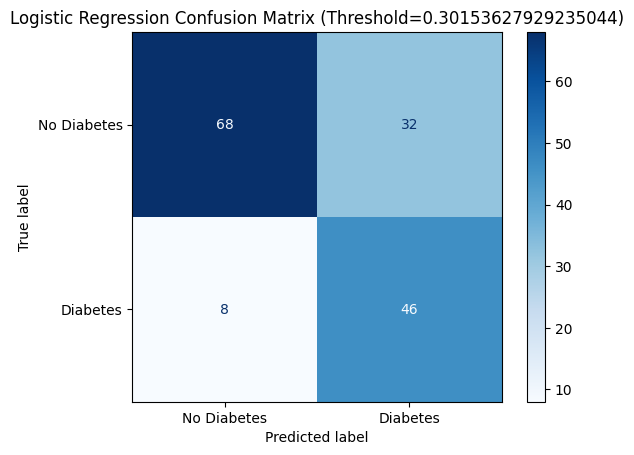

In [276]:
# Confusion Matrix - helps understand false positives and false negatives.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    # y_pred,
    display_labels=["No Diabetes", "Diabetes"],
    cmap="Blues",
    values_format="d"
)

plt.title(f"Logistic Regression Confusion Matrix (Threshold={threshold})")
plt.show()

In [277]:
cv_results = []

models = {
    "Logistic Regression": lr,
    "Tuned Logistic Regression": best_lr

}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_full,
        y_train_full,
        # X_train,
        # y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Mean ROC-AUC": scores.mean(),
        "CV Std": scores.std(),
        "Min Score": scores.min(),
        "Max Score": scores.max()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV Mean ROC-AUC",
    ascending=False
)

display(cv_results_df)

,Model,CV Mean ROC-AUC,CV Std,Min Score,Max Score
1,Tuned Logistic Regression,0.842400,0.026448,0.795349,0.866071
0,Logistic Regression,0.841596,0.028935,0.792151,0.868605


In [278]:
model_artifact = {
    "model": best_lr,
    "features": X.columns.tolist(),
    "target": "Outcome",
    "threshold": threshold
}

joblib.dump(
    model_artifact,
    "diabetes_prediction_model.pkl"
)

['diabetes_prediction_model.pkl']

In [279]:
# Inference Test

artifact = joblib.load("diabetes_prediction_model.pkl")
loaded_model = artifact["model"]

sample = X_test.iloc[[0]]

threshold = artifact["threshold"]

proba = loaded_model.predict_proba(sample)[0][1]
pred = int(proba >= threshold)

print(f"Probability of Diabetes: {proba:.3f}")
print(f"Threshold: {threshold}")
print(f"Prediction: {'Diabetes Risk' if pred else 'No Diabetes Risk'}")
print(f"Actual Label: {y_test.iloc[0]}")

Probability of Diabetes: 0.578
Threshold: 0.30153627929235044
Prediction: Diabetes Risk
Actual Label: 0


# Conclusion:

Selected Model: Tuned Logistic Regression

# Reason for Selection:
- CV ROC-AUC ≈ 0.842
- Stable across folds
- Highest F1 among tested models
- Very high recall after threshold optimization
- Easy to explain and deploy